# Feature Selection (Seleção de Variáveis)

### Biblioteca / Configuração

In [1]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [2]:
# Acesso aos modulos do diretório
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT)) 

# Manipulação dos dados
import pandas as pd
import numpy as np
import pickle

# Visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Diretórios
from config.paths import *

# Modelos / Machine Learning
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import permutation_importance

# Avisos
import warnings
warnings.filterwarnings('ignore')

# Configuração
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', None)

print('Ambiente Configurado')

Diretórios carregadas com sucesso
Ambiente Configurado


## Parâmetros Globais

In [3]:
# define a coluna alvo do modelo
TARGET = 'FPD'
# garante reprodutibilidade dos experimentos
RANDOM_STATE = 42
# quantidade de features mais relevantes a considerar
TOP_N_FEATURES = 30

### Carregamento dos dados 

In [4]:
# lê o arquivo parquet e carrega em um DataFrame
train = pd.read_parquet(PROCESSED_DIR / 'abt01_train.parquet')

print(f'📊 Treino: {train.shape}')
print(f'\n🎯 Distribuição do Target (Treino):')
print(f"  Treino: {(train[TARGET].value_counts(normalize=True) * 100).round(2)}")

📊 Treino: (831081, 119)

🎯 Distribuição do Target (Treino):
  Treino: FPD
0    76.82
1    23.18
Name: proportion, dtype: float64


## Preparação dos Dados

In [5]:
# Separar features e target
X_train = train.drop(TARGET, axis=1)
y_train = train[TARGET]

print(f'X_train: {X_train.shape}')

X_train: (831081, 118)


### Seleção de Variaveis

In [6]:
# Aplicando no treino
train_fs = X_train

# define X e y para treino
X_train = train_fs
y_train = train[TARGET] 

In [7]:
# Inicializa ExtraTrees para ranking de features
clf = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Treina o modelo
clf.fit(X_train, y_train)

# Importância padrão do ExtraTrees
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf.feature_importances_
}).sort_values(by="importance", ascending=False)

In [8]:
# Seleciona top N features mais relevantes
selected_features_fs = feat_imp.head(TOP_N_FEATURES)["feature"].tolist()
selected_features_df = feat_imp.head(TOP_N_FEATURES)

# Exibe quantidade de features selecionadas
print(f"Número de features selecionadas: {len(selected_features_fs)}")

Número de features selecionadas: 30


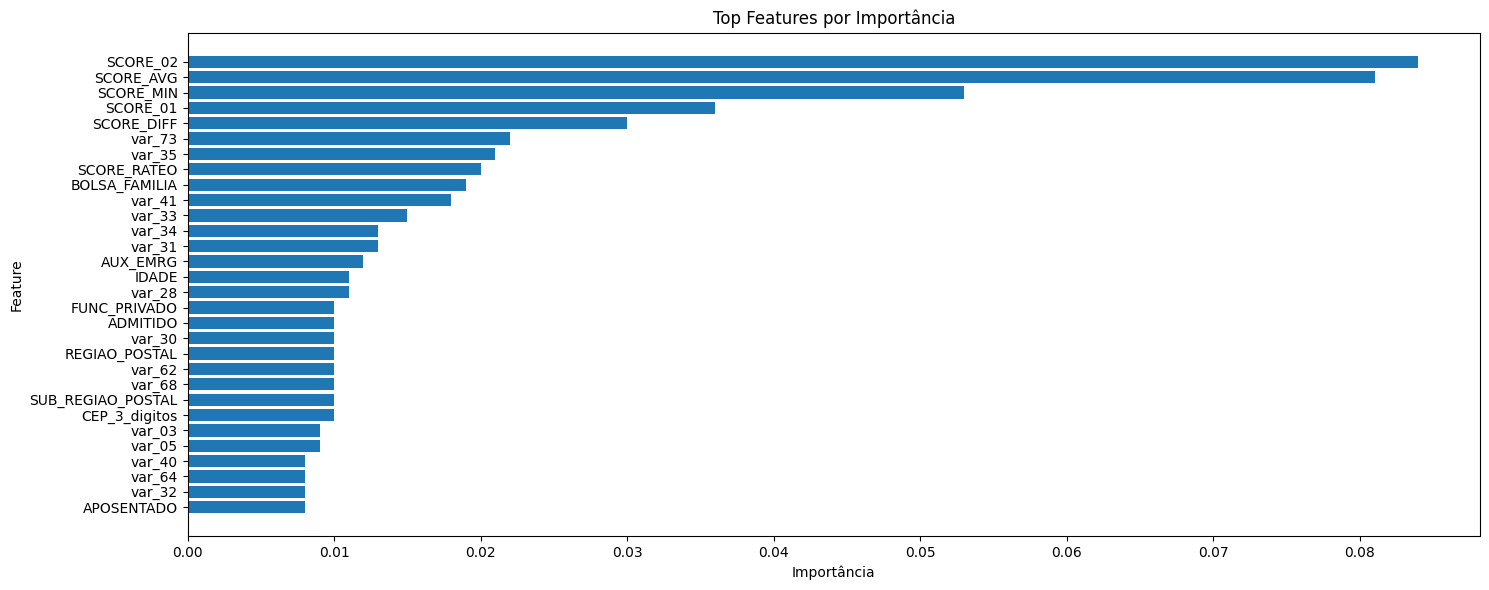

In [9]:
# Formata as importâncias com 3 casas decimais
feat_imp_table = feat_imp.sort_values(by="importance", ascending=False)
feat_imp_table["importance"] = feat_imp_table["importance"].round(3)

# Plotar importância das features (top N)
top_feats = feat_imp_table.head(TOP_N_FEATURES)

plt.figure(figsize=(15, 6))
plt.barh(top_feats['feature'], top_feats['importance'])
plt.gca().invert_yaxis()  # feature mais importante no topo
plt.title('Top Features por Importância')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [10]:
# Manter no X_train apenas as colunas selecionadas
X_train = X_train[selected_features_fs].copy()

### Correlação

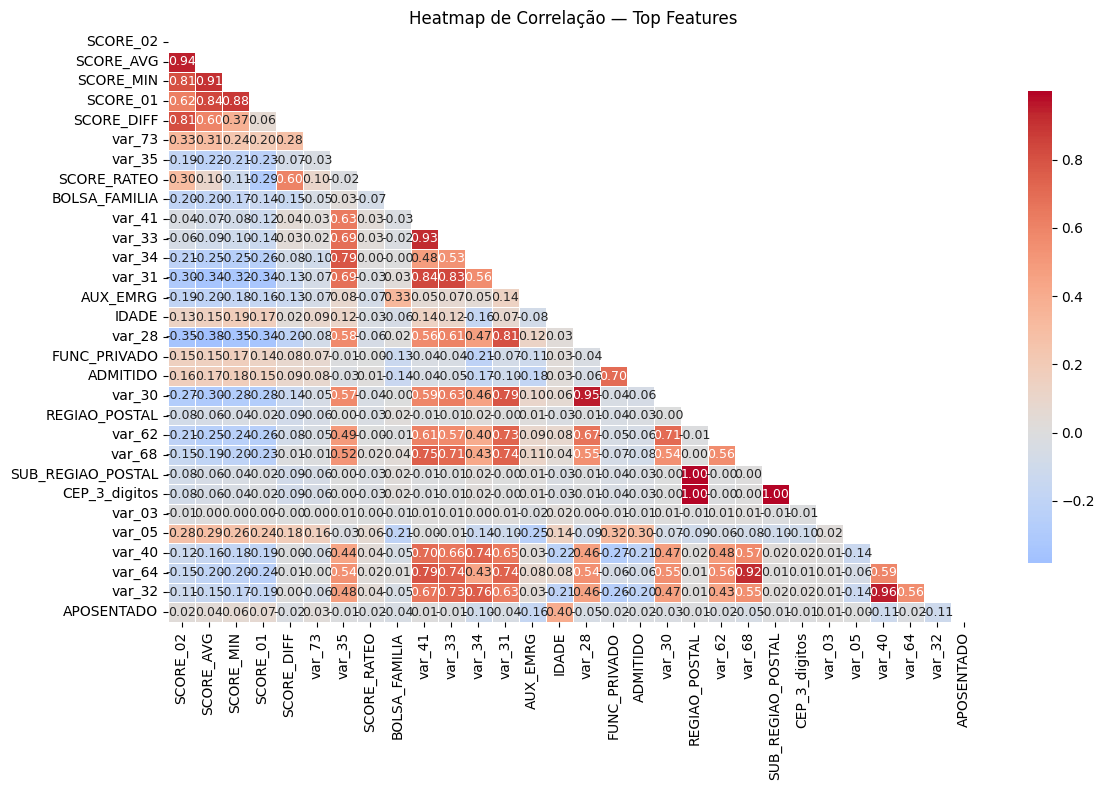

In [11]:
# calcula correlação apenas dessas features numéricas
corr = X_train.select_dtypes(include='number').corr()

# máscara para mostrar só metade da matriz
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap de Correlação — Top Features")
plt.tight_layout()
plt.show()


In [12]:
# Identificar pares de features com correlação absoluta acima do limiar

# calcula correlação apenas dessas features numéricas ignorando sinais
corr = X_train.select_dtypes(include='number').corr().abs()

# evita pares duplicados e remove a diagonal principal
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# percorre a matriz filtrada para encontrar pares altamente correlacionados
high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.8
]

# lista final de pares com alta correlação
high_corr_pairs

[('SCORE_02', 'SCORE_AVG', 0.9436237415882741),
 ('SCORE_02', 'SCORE_MIN', 0.8068370569448338),
 ('SCORE_AVG', 'SCORE_MIN', 0.9124901999290681),
 ('SCORE_AVG', 'SCORE_01', 0.8374333486448644),
 ('SCORE_MIN', 'SCORE_01', 0.8842014617811704),
 ('SCORE_02', 'SCORE_DIFF', 0.8140591376690891),
 ('var_41', 'var_33', 0.9261887964395865),
 ('var_41', 'var_31', 0.8393883295971581),
 ('var_33', 'var_31', 0.8343860882887348),
 ('var_31', 'var_28', 0.807273475647881),
 ('var_28', 'var_30', 0.9520485930228958),
 ('REGIAO_POSTAL', 'SUB_REGIAO_POSTAL', 0.9952170881945427),
 ('REGIAO_POSTAL', 'CEP_3_digitos', 0.9953042083994806),
 ('SUB_REGIAO_POSTAL', 'CEP_3_digitos', 0.9999339592177217),
 ('var_68', 'var_64', 0.9240578813927479),
 ('var_40', 'var_32', 0.9560588873597471)]

In [13]:
# Remover a feature menos importante entre pares altamente correlacionados

# Conjunto para armazenar features marcadas para remoção (evita duplicidade)
to_drop = set()

# percorre cada par de features com alta correlação
for f1, f2, _ in high_corr_pairs:
    
    # recupera a importância da primeira feature
    imp_f1 = feat_imp_table.loc[
        feat_imp_table['feature'] == f1, 'importance'
    ].values[0]
    
    # recupera a importância da segunda feature
    imp_f2 = feat_imp_table.loc[
        feat_imp_table['feature'] == f2, 'importance'
    ].values[0]

    # compara importâncias e marca para remoção a menos relevante
    if imp_f1 < imp_f2:
        to_drop.add(f1)
    else:
        to_drop.add(f2)

# lista final de features sugeridas para remoção
list(to_drop)

['var_28',
 'var_30',
 'var_32',
 'var_33',
 'var_31',
 'SUB_REGIAO_POSTAL',
 'SCORE_AVG',
 'SCORE_01',
 'SCORE_MIN',
 'var_64',
 'CEP_3_digitos',
 'SCORE_DIFF']

In [14]:
# Drop de colunas redundantes ou sem importância para feature selection
cols_to_drop = to_drop
X_train = X_train.drop(columns=cols_to_drop)

## Salvamento dos Dados Processados

In [15]:
# Reanexar target Para treino
X_train_final = X_train.copy()
X_train_final[TARGET] = train[TARGET].values

In [16]:
# salvar base de Treino tratada 
TRAIN_FILE = PROCESSED_DIR / 'abt01_train_fs.parquet'
print('\n💾 Salvando dados processados...')

# salvar dataset final
X_train_final.to_parquet(TRAIN_FILE, index=False)
print(f"✓ Treino salvo: {TRAIN_FILE}")
print('✅ Persistência concluída')


💾 Salvando dados processados...
✓ Treino salvo: C:\Users\billy.reis\Desktop\hackathon_dev\01_data\processed\abt01_train_fs.parquet
✅ Persistência concluída


In [17]:
# Salvar lista de features (excluindo a target) para referência futura
features_stage_02 = [c for c in X_train.columns if c != TARGET]

artifact_path = Path(ARTIFACT_DIR) / 'features_stage_02.pkl'

with open(artifact_path, 'wb') as f:
    pickle.dump(features_stage_02, f)

print(f'   ✓ Lista de features salva em: {artifact_path }')
print(f'\n✅ Todos os dados processados foram salvos')

   ✓ Lista de features salva em: C:\Users\billy.reis\Desktop\hackathon_dev\04_artifact\features_stage_02.pkl

✅ Todos os dados processados foram salvos
